# Exploratory Data Analysis: Amazon Reviews

Run this **after** `python src/data_download.py` and `python src/preprocess.py` have populated `data/processed/`. This notebook is not called by any script -- it's meant to be opened and run interactively whenever you want to look at the data.

All the heavy aggregation happens in Spark; only small, already-aggregated results are pulled into pandas for plotting, so this stays safe to run even though the full training set has ~3.6M rows.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

from src.config import TRAIN_PARQUET, get_spark_session

spark = get_spark_session("eda")
df = spark.read.parquet(str(TRAIN_PARQUET))
df.printSchema()
print(f"Rows: {df.count()}")

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/27 08:50:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- polarity: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- label: double (nullable = true)



Rows: 3600000


## Class balance

Is the dataset roughly 50/50 positive vs. negative, or skewed? This matters because a skewed dataset can make plain accuracy misleading (a model that always predicts the majority class would still score well) -- it's part of why `train.py` and `evaluate.py` also report F1 and AUC, not just accuracy.

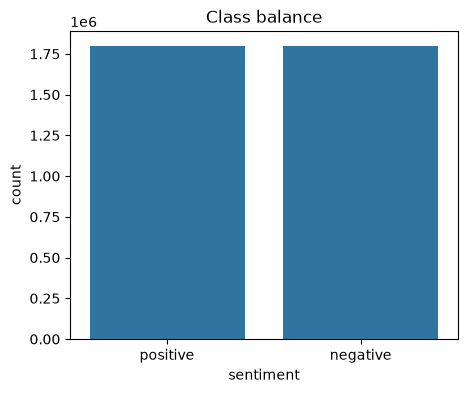

,label,count,sentiment
0,1.0,1800000,positive
1,0.0,1800000,negative


In [2]:
class_counts = (
    df.groupBy("label")
    .count()
    .toPandas()
    .assign(sentiment=lambda d: d["label"].map({0.0: "negative", 1.0: "positive"}))
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=class_counts, x="sentiment", y="count", ax=ax)
ax.set_title("Class balance")
plt.show()
class_counts

## Review length distribution

Do positive and negative reviews tend to differ in length? We compute word count per review in Spark, then sample down to a manageable number of rows before pulling into pandas for the histogram -- plotting all 3.6M points would be both slow and visually useless.

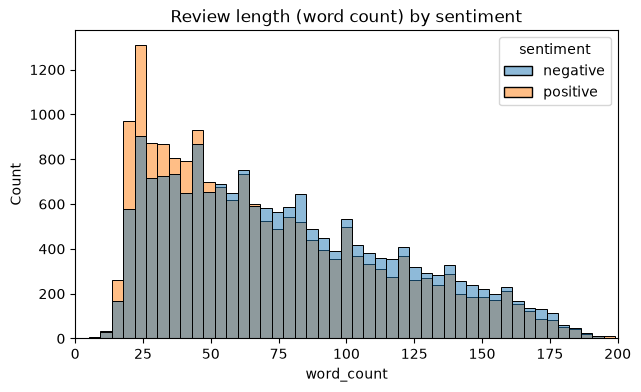

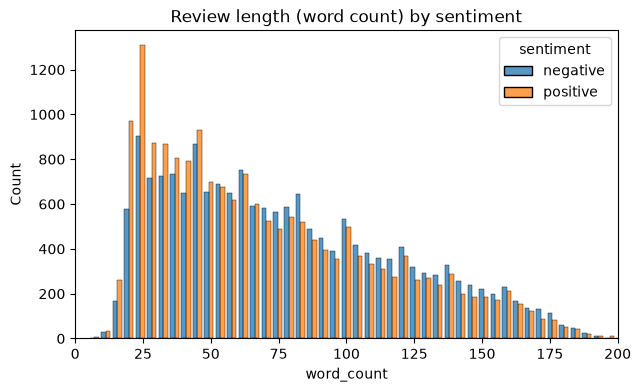

In [5]:
with_length = df.withColumn("word_count", F.size(F.split(F.col("text"), r"\s+")))

sample_pd = (
    with_length.select("label", "word_count")
    .sample(fraction=0.01, seed=42)  # ~36K rows -- plenty for a histogram, cheap to collect
    .toPandas()
)
sample_pd["sentiment"] = sample_pd["label"].map({0.0: "negative", 1.0: "positive"})

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=sample_pd, x="word_count", hue="sentiment", bins=50, ax=ax)
ax.set_xlim(0, 200)
ax.set_title("Review length (word count) by sentiment")
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=sample_pd,
    x="word_count",
    hue="sentiment",
    bins=50,
    multiple="dodge",
    shrink=0.8,
    ax=ax,
)
ax.set_xlim(0, 200)
ax.set_title("Review length (word count) by sentiment")
plt.show()

## Most common words per class

A quick, unweighted look at which words show up most often in positive vs. negative reviews (after lowercasing and a naive stopword filter). Uses `review_text` (title + body combined, see `../model_plan.md`) since that's what the real pipeline's `HashingTF`/`IDF` actually operate on — see `02_pipeline_walkthrough.ipynb` for the full transformer-by-transformer walkthrough.

In [ ]:
from pyspark.ml.feature import StopWordsRemover, Tokenizer

tokenized = Tokenizer(inputCol="review_text", outputCol="words").transform(df)
filtered = StopWordsRemover(inputCol="words", outputCol="filtered_words").transform(tokenized)

top_words = (
    filtered.select("label", F.explode("filtered_words").alias("word"))
    .groupBy("label", "word")
    .count()
    .orderBy(F.desc("count"))
    .limit(40)  # small, safe to collect
    .toPandas()
)
top_words["sentiment"] = top_words["label"].map({0.0: "negative", 1.0: "positive"})

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=top_words.sort_values("count"), y="word", x="count", hue="sentiment", ax=ax)
ax.set_title("Most frequent words (top 40 overall, by sentiment)")
plt.show()

In [6]:
spark.stop()